</table><table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 17 - Ejemplo 3 - Árboles de decisión
        </td>
    </tr>
    <tr>
 

</table>

In [1]:
import numpy as np
import pandas as pd
import array
import matplotlib.pyplot as plt
import seaborn as sns
import math
from plotnine import *
from array import*
import scipy.stats as stats
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import os, sys

from Parcial2.Parcial2_20231085 import random_state

Se dispone del conjunto de datos `load_diabetes` de la librería `sklearn.datasets`, el cual contiene información médica de pacientes relacionada con la progresión de la diabetes.

El objetivo es construir un modelo de árbol de decisión para regresión que permita predecir la variable `target`, la cual representa una medida cuantitativa de la progresión de la enfermedad un año después de la medición inicial.

Las variables predictoras son: `age`, `sex`, `bmi`, `bp`, `s1`, `s2`, `s3`, `s4`, `s5` y `s6`.

A partir de estas variables, el árbol de decisión dividirá el espacio de predictores en diferentes regiones, asignando a cada región un valor promedio de predicción para la variable `target`.

a) Cargar el conjunto de datos `load_diabetes`.

b) Convertir los datos en un `DataFrame`.

c) Realizar un análisis gráfico de los datos.

d) Dividir el conjunto de datos en 20% para la validación.

e) Crear un árbol de decisión con parámetros por defecto.

f) Crear un árbol de decisión con `max_depth=3`.

g) Crear un árbol de decisión con `min_samples_leaf=8`.

i) Aplicar validación cruzada para seleccionar la mejor profundidad máxima.

j) Entrenar un modelo final con la profundidad óptima y predecir el valor de `target` para un paciente con los valores promedio de las variables independientes.

In [2]:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y=True,  as_frame=True)

In [3]:
X

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [4]:
y

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

<Figure size 640x480 with 0 Axes>

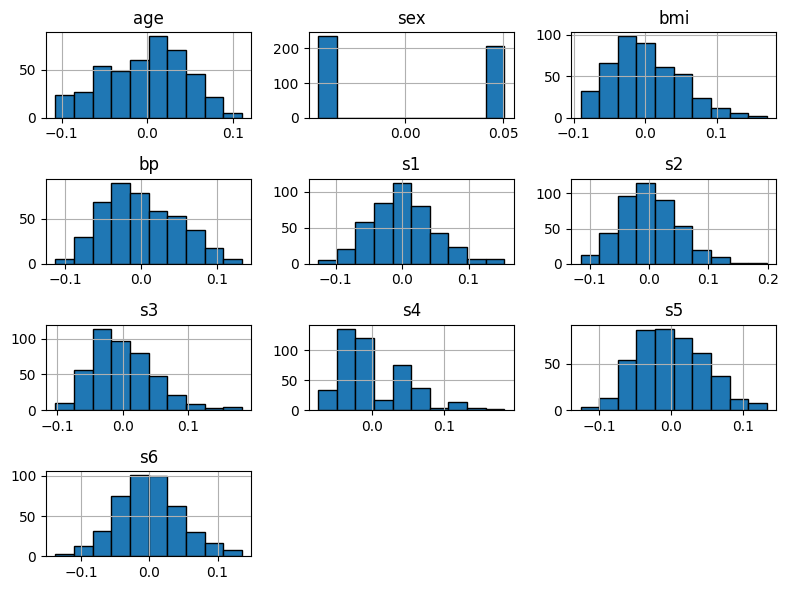

In [10]:
#Elaborar histograma
plt.figure()
X.hist(figsize=(8,6), edgecolor="black")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

#Obtenemos las muestras de entrenamiento y test por medio de la función train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.20, random_state=2026)

In [6]:
from sklearn.tree import DecisionTreeRegressor

#Crear el objeto de clase árbol
tree_clf = DecisionTreeRegressor(random_state = 2026)
#Ajustar el arbol
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max

In [7]:
#Obtener el accuracy_score
y_pred_a = tree_clf.predict(X_test)
mse_a = mean_squared_error(y_test, y_pred_a)
r2_a = r2_score(y_test, y_pred_a)
print("El error cuadrático medio que se tiene es %s" %mse_a)
print("El valor del r2 que se tiene es %s" %r2_a)

El error cuadrático medio que se tiene es 6694.865168539326
El valor del r2 que se tiene es -0.12775683558951223


El árbol de decisión con parámetros por defecto no presenta un buen desempeño predictivo para este problema de regresión. El MSE obtenido es alto y el valor negativo de $R^2$ muestra que el modelo predice peor que una estimación basada en el promedio de la variable objetivo. Por esta razón, es necesario ajustar hiperparámetros como la profundidad máxima del árbol o el número máximo de nodos hoja, con el fin de obtener un modelo más simple, estable y con mejor capacidad de generalización.

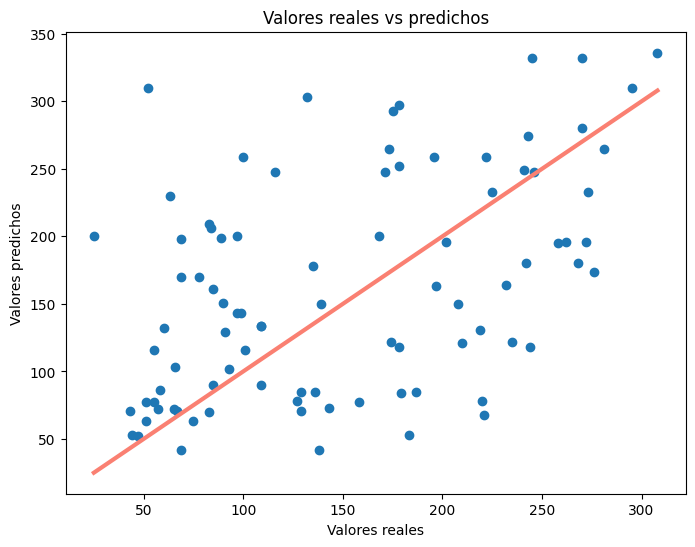

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_a)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='salmon',linewidth='3')
plt.show()

In [15]:
##Crear el objeto de clase árbol profundidad max de 3
tree_clf_b = DecisionTreeRegressor(random_state = 2026, max_depth = 3)
#Ajustar el árbol
tree_clf_b.fit(X_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_le

In [16]:
#Obtener el mse y el r2
y_pred_b = tree_clf_b.predict(X_test)
mse_b = mean_squared_error(y_test, y_pred_b)
r2_b = r2_score(y_test, y_pred_b)
print("El error cuadratico medio que se tiene es %s" %mse_b)
print("El r2 que se tiene es %s" %r2_b)

El error cuadratico medio que se tiene es 3803.0146291599435
El r2 que se tiene es 0.3593783241466265


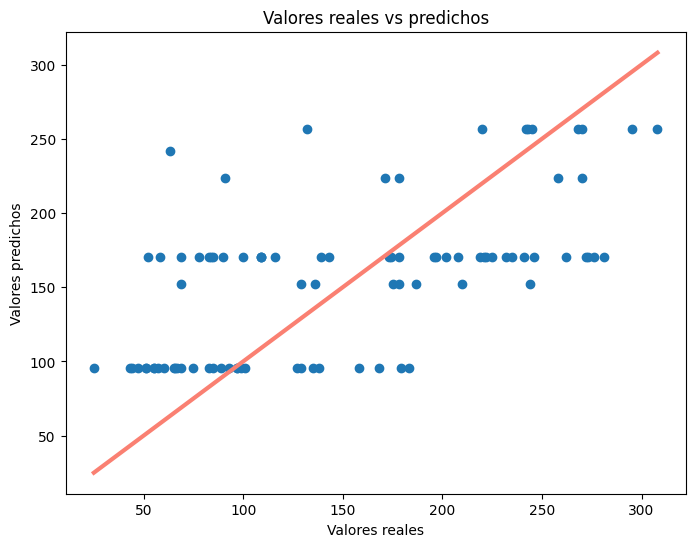

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_b)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='salmon', linewidth='3')
plt.show()

El valor de del $R^2$ de 0.3594 indica que el modelo logra explicar aproximadamente el 35.94 % de la variabilidad en la progresión de la diabetes. Aunque este valor no es alto, representa una mejora considerable respecto al modelo sin ajuste de hiperparámetros, el cual obtuvo un $R^2$ negativo

In [21]:
#Árbol con al menos 8 muestra en casa hoja
tree_clf_c = DecisionTreeRegressor(random_state = 2026, min_samples_leaf = 8)
#Ajustar el árbol
tree_clf_c.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max

In [22]:
#Obtener el mse y el r2
y_pred_c = tree_clf_c.predict(X_test)
mse_c = mean_squared_error(y_test, y_pred_c)
r2_c = r2_score(y_test, y_pred_c)
print("El error cuadratico medio que se tiene es %s" %mse_c)
print("El r2 que se tiene es %s" %r2_c)

El error cuadratico medio que se tiene es 4271.74328417093
El r2 que se tiene es 0.28042050626414183


In [23]:
#Obtener el accuracy_score
y_pred_c= tree_clf_c.predict(X_test)
mse_c = mean_squared_error(y_test, y_pred_c)
r2_c = r2_score(y_test, y_pred_c)
print("El error cuadrático medio que se tiene es %s" %mse_c)
print("El valor del r2 que se tiene es %s" %r2_c)

El error cuadrático medio que se tiene es 4271.74328417093
El valor del r2 que se tiene es 0.28042050626414183


El modelo con min_samples_leaf=8 presenta una mejora respecto al árbol con parámetros por defecto, ya que reduce el MSE y obtiene un $R^2$ positivo. Esto sugiere que exigir un mínimo de 8 observaciones por hoja ayuda a controlar el sobreajuste del árbol. Sin embargo, al compararlo con el modelo max_depth=3, su desempeño es inferior, pues obtiene un MSE más alto y un $R^2$ menor. Por tanto, entre los modelos evaluados hasta este momento, el árbol con profundidad máxima de 3 sigue mostrando el mejor rendimiento predictivo.

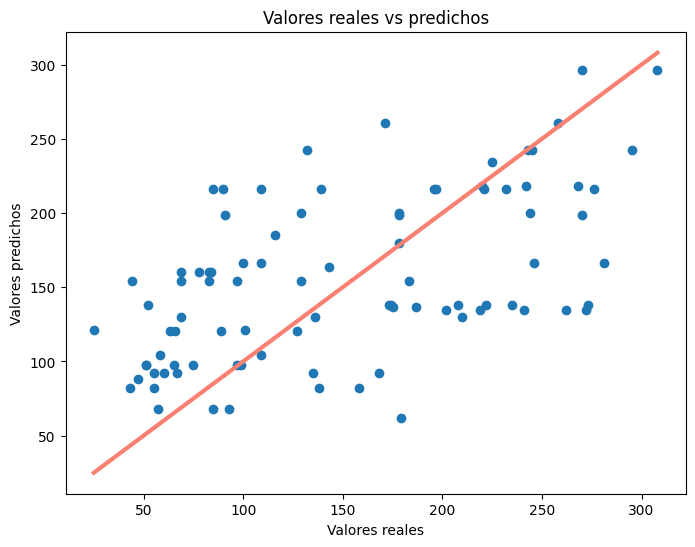

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_c)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='salmon', linewidth='3')
plt.show()

In [28]:
from sklearn import tree
from sklearn.model_selection import cross_val_score

k_range = range(3,100)
depth = list()
for i in k_range:
    clf = tree.DecisionTreeRegressor(min_samples_leaf=i, random_state=2026)
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train, scoring="r2", cv=10, n_jobs=4)
    depth.append(scores.mean())

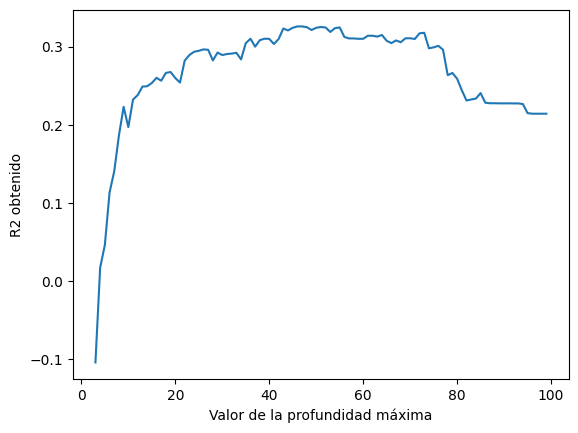

In [29]:
#Representar la validación cruzada
plt.plot(k_range, depth)
plt.xlabel('Valor de la profundidad máxima')
plt.ylabel('R2 obtenido')
plt.show()

In [30]:
print("El valor de K que maximiza el r^2 es", np.argmax(depth) + 3)

El valor de K que maximiza el r^2 es 46


In [32]:
#árbol con 46 muestras en cada hoja

#Crear el objeto de clase árbol
tree_clf_d = DecisionTreeRegressor(min_samples_leaf= 46, random_state=2026)
#ajustar árbol
tree_clf_d.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",46
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"ma

In [33]:
#Realizamos una predicción sobre la media
X_media =np.mean(X, axis=0)
pred_media = tree_clf_d.predict(X_media.values.reshape(1,-1))

C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


In [34]:
print("La predicción obtenida es de %s" %pred_media)

La predicción obtenida es de [158.45652174]
